# Kvalitet i predobrada tekstualnih podataka: klasifikacija SMS poruka (spam/ham)

Tok pripreme kratkih tekstualnih poruka za mašinsko učenje: od analize kvaliteta sirovog teksta, preko tokenizacije, normalizacije, uklanjanja stop-reči, POS-svesne lematizacije i augmentacije podataka (EDA + poređenje agresivne i pažljive predobrade), do poređenja uticaja tih koraka na tri različite reprezentacije teksta (Bag-of-Words/TF-IDF, Word2Vec/FastText, DistilBERT).

Poredimo **tri** verzije teksta kroz ceo eksperiment:
- **sirov tekst** - samo case folding, bez ičeg drugog,
- **agresivna predobrada** - normalizacija + uklanjanje stop-reči + lematizacija, gde se brojevi/valute/velika slova tretiraju kao šum i uklanjaju,
- **pažljiva predobrada** - ista lingvistička obrada, ali diskriminativni signali (brojevi, valute, velika slova, ponovljena interpunkcija) se čuvaju kao eksplicitne oznake umesto da se brišu.

**Skup podataka:** SMS Spam Collection (5.572 poruka, engleski jezik, oznake `ham`/`spam`).

In [1]:
import re
import string
import random
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer

import contractions
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

## 1. Učitavanje podataka

Skup je u tab-separated formatu, dve kolone: oznaka klase i tekst poruke.

In [2]:
df = pd.read_csv("sms_raw.tsv", sep="\t", header=None, names=["label", "message"], encoding="utf-8")
print(df.shape)
df.head(10)

(5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


Skup ima 5.572 poruke, dve kolone (`label`, `message`). Već u prvih 10 redova vide se tipični obrasci: ham poruke liče na svakodnevnu konverzaciju ("Ok lar... Joking wif u oni..."), dok se spam poruke ističu velikim slovima, uzvičnicima i pozivima na akciju ("WINNER!!", "FreeMsg", "Had your mobile 11 months or more?").

## 2. Provera kvaliteta podataka: nedostajuće vrednosti i duplikati

Pre bilo kakve lingvističke obrade, prvo se proverava osnovni kvalitet skupa. Duplikati su posebno bitni kod ovakvih skupova: ako ista poruka završi i u trening i u test skupu, model se ne ocenjuje pošteno (curenje podataka), pa se precenjuje njegova stvarna tačnost.

In [3]:
print("Nedostajuće vrednosti:")
print(df.isna().sum())
print()
print("Potpuno identičnih poruka:", df.duplicated(subset=["message"]).sum())

df = df.drop_duplicates(subset=["message"]).reset_index(drop=True)
print("Broj poruka nakon uklanjanja duplikata:", len(df))

Nedostajuće vrednosti:
label      0
message    0
dtype: int64

Potpuno identičnih poruka: 403
Broj poruka nakon uklanjanja duplikata: 5169


Nema nedostajućih vrednosti, ali je pronađeno 403 potpuno identične poruke (7,2% skupa) - verovatno posledica ponovljenih reklamnih šablona kod spam pošiljalaca. Nakon uklanjanja duplikata ostaje 5.169 poruka. Ovaj korak nije kozmetički: da su duplikati ostali, ista poruka mogla je da se nađe i u trening i u test skupu, pa bi model na testu delovao bolje nego što zaista jeste (curenje podataka).

## 3. Raspodela klasa

Skupovi za detekciju spama su po prirodi neuravnoteženi (spam je manjinska klasa), što je bitno imati u vidu kasnije prilikom podele na trening/test skup i izbora metrika (F1/precision/recall umesto same tačnosti).

label
ham     4516
spam     653
Name: count, dtype: int64

label
ham     87.37
spam    12.63
Name: proportion, dtype: float64


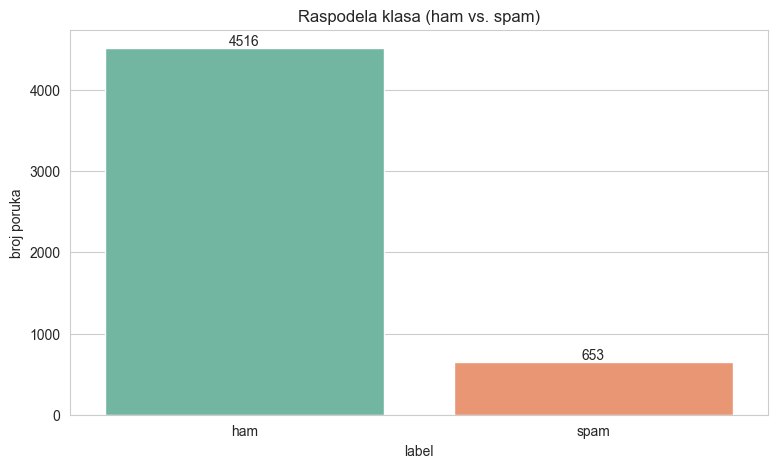

In [4]:
class_counts = df["label"].value_counts()
class_pct = df["label"].value_counts(normalize=True) * 100
print(class_counts)
print()
print(class_pct.round(2))

fig, ax = plt.subplots()
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette="Set2", legend=False, ax=ax)
ax.set_ylabel("broj poruka")
ax.set_title("Raspodela klasa (ham vs. spam)")
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 30, str(v), ha="center")
plt.show()

Rezultat: 4.516 ham poruka (87,4%) i 653 spam poruke (12,6%) - odnos otprilike 7:1. Ovakav disbalans znači da tačnost (accuracy) sama po sebi nije pouzdana mera kvaliteta modela (model koji uvek predviđa "ham" već ima ~87% tačnosti), pa se u nastavku prati prevashodno F1-mera za spam klasu.

## 4. Dužina dokumenata

Dužina poruke (u karakterima i rečima) često nosi sama po sebi diskriminativnu informaciju - spam poruke su po pravilu duže jer sadrže reklamni tekst, pozive na akciju, brojeve telefona i linkove.

In [5]:
df["n_chars"] = df["message"].str.len()
df["n_words"] = df["message"].str.split().apply(len)

df.groupby("label")[["n_chars", "n_words"]].describe().T

label                  ham        spam
n_chars count  4516.000000  653.000000
        mean     70.905890  137.704441
        std      56.715046   29.821348
        min       2.000000   13.000000
        25%      34.000000  132.000000
        50%      53.000000  148.000000
        75%      91.000000  157.000000
        max     910.000000  223.000000
n_words count  4516.000000  653.000000
        mean     14.239814   23.739663
        std      11.179471    5.931064
        min       1.000000    2.000000
        25%       7.000000   22.000000
        50%      11.000000   25.000000
        75%      19.000000   28.000000
        max     171.000000   35.000000

Spam poruke su dosledno duže i mnogo uniformnije po dužini - prosečno 137,7 karaktera (std 29,8; opseg 13–223) i 23,7 reči, što odgovara reklamnim porukama pisanim do granice od ~160 karaktera po SMS-u. Ham poruke su, nasuprot tome, mnogo raznovrsnije - prosek 70,9 karaktera, ali sa ogromnim rasponom (std 56,7; od 2 do 910 karaktera) i 14,2 reči u proseku, jer pokrivaju sve od jednorečnih odgovora do dugih razgovora. Dužina poruke je, dakle, sama po sebi već korisna diskriminativna karakteristika.

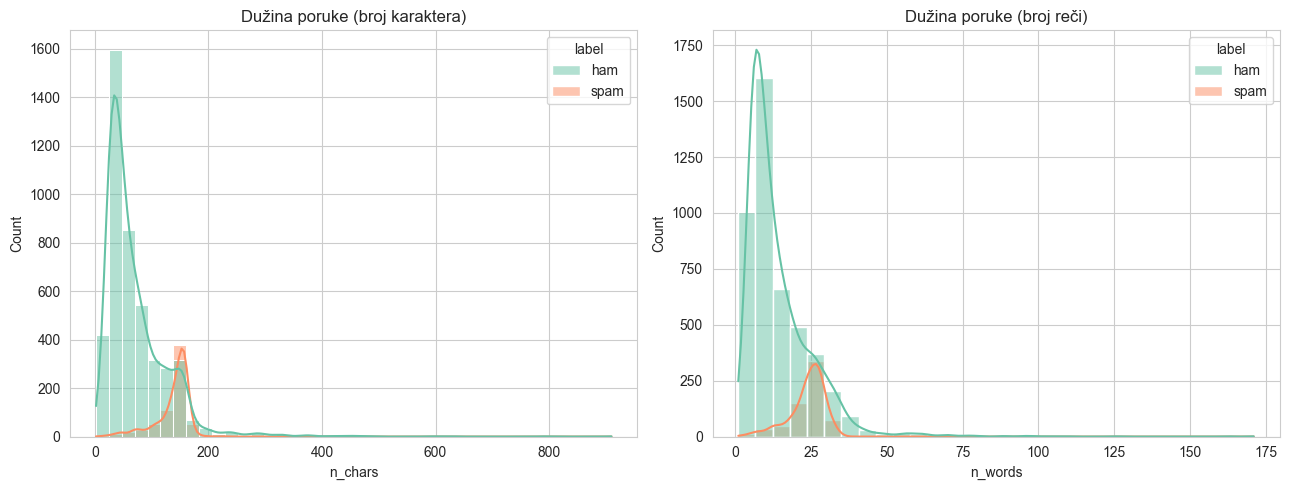

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(data=df, x="n_chars", hue="label", bins=40, kde=True, ax=axes[0], palette="Set2")
axes[0].set_title("Dužina poruke (broj karaktera)")
sns.histplot(data=df, x="n_words", hue="label", bins=30, kde=True, ax=axes[1], palette="Set2")
axes[1].set_title("Dužina poruke (broj reči)")
plt.tight_layout()
plt.show()

Histogrami potvrđuju brojke iznad: raspodela dužine ham poruka je izrazito desno zakošena, sa vrhom kod kratkih poruka (10–30 karaktera) i dugim repom prema ređim, mnogo dužim porukama. Spam poruke, nasuprot tome, formiraju uzak, gotovo simetričan brežuljak koncentrisan između ~120 i ~160 karaktera - vidljiv trag toga da su generisane iz sličnih reklamnih šablona.

## 5. Veličina rečnika (vocabulary size) i leksička raznovrsnost (TTR)

Type-Token Ratio (TTR = broj jedinstvenih reči / ukupan broj reči) meri leksičku raznovrsnost: viša vrednost znači da tekst manje ponavlja iste reči. Poredimo ham i spam poruke odvojeno - spam poruke po pravilu koriste manji, ali agresivnije ponavljan skup reči (pozivi na akciju, brojevi, "free", "win", "call").

In [7]:
def basic_tokenize(text):
    return re.findall(r"[a-zA-Z']+", text.lower())

df["tokens_raw"] = df["message"].apply(basic_tokenize)

def vocab_stats(token_lists):
    all_tokens = [t for toks in token_lists for t in toks]
    vocab = set(all_tokens)
    ttr = len(vocab) / len(all_tokens) if all_tokens else 0
    return len(all_tokens), len(vocab), ttr

rows = []
for label in ["ham", "spam"]:
    n_tok, n_vocab, ttr = vocab_stats(df.loc[df.label == label, "tokens_raw"])
    rows.append({"klasa": label, "ukupno tokena": n_tok, "veličina rečnika": n_vocab, "TTR": round(ttr, 4)})
pd.DataFrame(rows)

,klasa,ukupno tokena,veličina rečnika,TTR
0,ham,63906,6913,0.1082
1,spam,14832,2127,0.1434


Ham poruke ukupno sadrže 63.906 tokena sa rečnikom od 6.913 jedinstvenih reči (TTR = 0,1082), dok spam poruke sadrže 14.832 tokena sa rečnikom od 2.127 reči (TTR = 0,1434). Na prvi pogled deluje neintuitivno da spam ima *veću* leksičku raznovrsnost - ali ovo je klasična zamka TTR mere: ona sistematski opada sa veličinom uzorka (veći korpus ima veću šansu da ponovi već viđenu reč), pa manji spam korpus automatski dobija veći TTR. Ispravno poređenje bi zahtevalo uzorke jednake dužine ili robusniju meru poput MTLD.

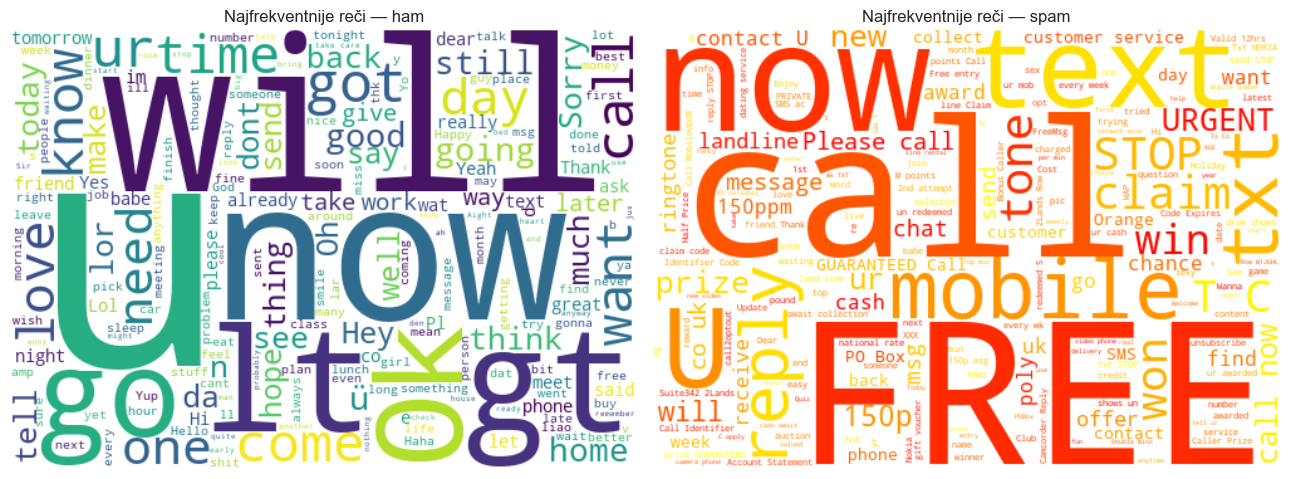

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for label, color in zip(["ham", "spam"], ["#4C72B0", "#DD8452"]):
    text = " ".join(df.loc[df.label == label, "message"])
    wc = WordCloud(width=500, height=350, background_color="white", colormap="viridis" if label == "ham" else "autumn").generate(text)
    ax = axes[0] if label == "ham" else axes[1]
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"Najfrekventnije reči — {label}")
    ax.axis("off")
plt.tight_layout()
plt.show()

Iako se word cloud generiše nad sirovim tekstom (pre uklanjanja stop-reči), kod spam klase kroz gomilu čestih engleskih reči već probijaju sadržajne reči karakteristične za reklamni ton — "call", "free", "now", "txt", "stop", "mobile". Kod ham poruka dominiraju gotovo isključivo funkcionalne reči ("i", "you", "to", "the", "u", "me"), bez izražene tematske grupe.

Word cloud daje osećaj koje reči dominiraju, ali ne i tačan broj pojavljivanja. Sledeći grafik to dopunjuje brojkama.

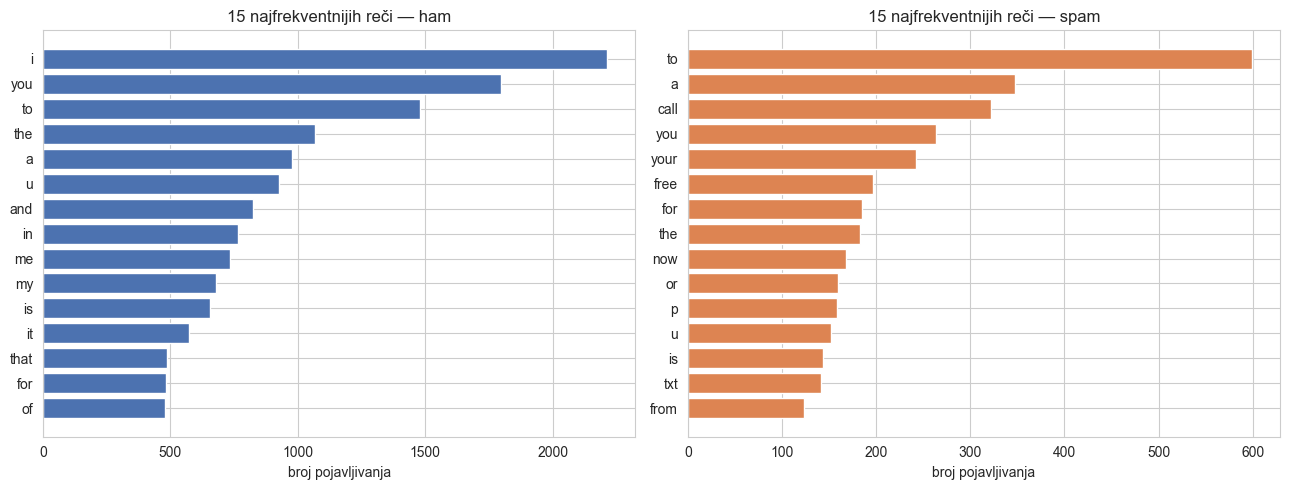

In [9]:
from collections import Counter

def top_words(messages, n=15):
    counter = Counter()
    for m in messages:
        counter.update(basic_tokenize(m))
    return counter.most_common(n)

ham_top = top_words(df.loc[df.label == "ham", "message"])
spam_top = top_words(df.loc[df.label == "spam", "message"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh([w for w, _ in ham_top][::-1], [c for _, c in ham_top][::-1], color="#4C72B0")
axes[0].set_title("15 najfrekventnijih reči — ham")
axes[0].set_xlabel("broj pojavljivanja")
axes[1].barh([w for w, _ in spam_top][::-1], [c for _, c in spam_top][::-1], color="#DD8452")
axes[1].set_title("15 najfrekventnijih reči — spam")
axes[1].set_xlabel("broj pojavljivanja")
plt.tight_layout()
plt.show()

Grafik potvrđuje brojkama ono što je word cloud samo nagovestio. Kod ham poruka apsolutni vrh liste su čisto funkcionalne reči ("i", "you", "to", "the") - nema nijedne tematske reči u top 15, u skladu sa očekivanjem da svakodnevna konverzacija nema zajedničku temu. Kod spam poruka slika je sasvim drugačija: odmah posle funkcionalnih reči ("to", "a") probijaju se jasno tematske, reklamne reči - "call", "free", "now", "txt" - i to je upravo signal koji BoW/TF-IDF modeli hvataju i koji postaje jedan od najjačih prediktora spama.

## 6. Šum u tekstu

Kod SMS poruka šum ne dolazi u obliku HTML tagova (to je tipičnije za tekst sa veba), već u obliku telefonskih brojeva i skraćenih linkova, pisanja velikim slovima radi naglašavanja, ponovljene interpunkcije, valutnih simbola i sličnih artefakata karakterističnih za reklamni tekst.

In [10]:
def count_pattern(series, pattern, case_sensitive=False):
    return series.str.contains(pattern, regex=True, case=case_sensitive).sum()

patterns = {
    "URL / web adresa": (r"(www\.|http|\.com|\.co\.uk)", False),
    "dugi niz cifara (4+, npr. broj telefona)": (r"\d{4,}", False),
    "ALL CAPS reč (3+ slova)": (r"\b[A-Z]{3,}\b", True),
    "ponovljena interpunkcija (!!, ??, ...)": (r"[!?]{2,}", False),
    "valutni simbol (£ $ €)": (r"[£$€]", False),
}
noise_counts = {name: count_pattern(df["message"], pat, cs) for name, (pat, cs) in patterns.items()}
noise_df = pd.Series(noise_counts, name="broj poruka").sort_values(ascending=False).to_frame()
noise_df["% od skupa"] = (noise_df["broj poruka"] / len(df) * 100).round(2)
noise_df

,broj poruka,% od skupa
ALL CAPS reč (3+ slova),743,14.37
"dugi niz cifara (4+, npr. broj telefona)",548,10.60
valutni simbol (£ $ €),236,4.57
URL / web adresa,128,2.48
"ponovljena interpunkcija (!!, ??, ...)",92,1.78


Nakon ispravke provere za velika slova (prvobitno je bila case-insensitive, pa je lažno prijavljivala 99,8% poruka), stvarna slika šuma je: 14,4% poruka sadrži reč napisanu celu velikim slovima, 10,6% sadrži dug niz cifara, 4,6% sadrži simbol valute, 2,5% sadrži URL, a 1,8% ima ponovljenu interpunkciju. Ovi obrasci nisu ravnomerno raspoređeni između klasa - gotovo su isključivo obeležje spam poruka, što opravdava njihovo očuvanje kao eksplicitnog signala (odeljak 12), a ne prosto brisanje.

Ovaj konkretan skup nastao je pre masovne upotrebe emotikona u SMS porukama, pa u njemu nema emoji karaktera niti HTML entiteta. Pošto su to čest izvor šuma kod novijeg tekstualnog sadržaja sa interneta i društvenih mreža, u nastavku je dat kratak **ilustrativni primer** dve veštački sastavljene poruke sa emoji simbolima i HTML ostacima na kojima se stvarno pokreće naš pipeline za normalizaciju, da se vidi tačno šta se briše, a šta ostaje.

## 7. Tokenizacija: reč / rečenica / podreč (subword)

Tri nivoa tokenizacije rešavaju različite probleme:
- **rečenična** tokenizacija deli tekst na rečenice (bitno kod dužih dokumenata, manje kod kratkih SMS poruka koje su često jedna rečenica),
- **tokenizacija na nivou reči** je standard za klasične BoW/TF-IDF i word embedding modele,
- **subword (WordPiece)** tokenizacija, koju koriste transformer modeli poput BERT-a, razbija retke/nepoznate reči na poznate delove, čime se rešava problem out-of-vocabulary (OOV) reči bez potrebe za ogromnim rečnikom.

In [11]:
from transformers import AutoTokenizer

bert_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

sample = df.loc[df["message"].str.len() > 120, "message"].iloc[0]
print("PRIMER PORUKE:\n", sample, "\n")

print("Rečenična tokenizacija:")
print(sent_tokenize(sample))
print()

print("Tokenizacija na nivou reči (word-level):")
print(word_tokenize(sample))
print()

print("Subword (WordPiece) tokenizacija:")
print(bert_tokenizer.tokenize(sample))

PRIMER PORUKE:
 Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's 

Rečenična tokenizacija:
['Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005.', "Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"]

Tokenizacija na nivou reči (word-level):
['Free', 'entry', 'in', '2', 'a', 'wkly', 'comp', 'to', 'win', 'FA', 'Cup', 'final', 'tkts', '21st', 'May', '2005', '.', 'Text', 'FA', 'to', '87121', 'to', 'receive', 'entry', 'question', '(', 'std', 'txt', 'rate', ')', 'T', '&', 'C', "'s", 'apply', '08452810075over18', "'s"]

Subword (WordPiece) tokenizacija:
['free', 'entry', 'in', '2', 'a', 'w', '##k', '##ly', 'com', '##p', 'to', 'win', 'fa', 'cup', 'final', 't', '##kt', '##s', '21st', 'may', '2005', '.', 'text', 'fa', 'to', '87', '##12', '##1', 'to', 'receive', 'entry', 'question', '(', 'st', '##d', 'tx', '##t', 'rate', ')', 't', '&', '

Na primeru spam poruke sa brojevima i skraćenicama, rečenična tokenizacija ispravno prepoznaje dve rečenice (razdvojene tačkom posle "2005."). Word-level tokenizacija (37 tokena) tretira brojeve i skraćenice kao zasebne, glomazne celine - "87121" i "08452810075over18" ostaju netaknuti, glomazni tokeni. Subword (WordPiece) tokenizacija istu poruku deli na 54 podreči: nepoznata reč "wkly" postaje "w" + "##k" + "##ly", a dugačak broj "08452810075over18" se razbija na niz kraćih fragmenata. Ovo direktno pokazuje zašto subword pristup rešava problem nepoznatih reči (OOV): umesto da ceo redak broj ili žargonska skraćenica postane jedan nepoznat token, model radi sa manjim, prethodno viđenim gradivnim blokovima.

## 8. Normalizacija

Normalizacija obuhvata Unicode normalizaciju (NFKC), case folding (svođenje na mala slova), proširivanje skraćenih oblika (npr. *"can't"* → *"can not"*) i zamenu varijabilnih entiteta (URL-ovi, brojevi) generičkim oznakama - čime se smanjuje veličina rečnika bez gubitka bitne informacije o *tipu* sadržaja.

In [4]:
def normalize_text(text):
    text = unicodedata.normalize("NFKC", text)
    text = text.lower()
    text = contractions.fix(text)
    text = re.sub(r"(www\.\S+|http\S+|\S+\.com\S*)", " URL ", text)
    text = re.sub(r"\d{4,}", " NUM ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["normalized"] = df["message"].apply(normalize_text)
df[["message", "normalized"]].sample(8, random_state=42)

,message,normalized
1566,"K, makes sense, btw carlos is being difficult ...",k makes sense by the way carlos is being diffi...
1988,"URGENT! Your mobile No *********** WON a £2,00...",urgent your mobile no won a bonus caller prize...
1235,If you still havent collected the dough pls le...,if you still have not collected the dough pls ...
2868,Wat time do u wan 2 meet me later?,wat time do you wan meet me later
3435,"You can stop further club tones by replying ""S...",you can stop further club tones by replying st...
1471,Check wid corect speling i.e. Sarcasm,check wid corect speling i e sarcasm
1129,Hey! There's veggie pizza... :/,hey there is veggie pizza
3747,"Hey, I missed you tm of last night as my phone...",hey i missed you tm of last night as my phone ...


Normalizacija ispravno svodi tekst na mala slova, širi neformalne skraćenice (npr. "u" → "you") i uklanja interpunkciju i brojeve. Vidi se i ograničenje pravila: pojedinačne cifre koje se koriste kao zamena za reč (npr. "2" umesto "to") jednostavno nestaju umesto da se ispravno prevedu, jer pravilo za brojeve cilja samo duže nizove cifara (4+, telefonski brojevi), ne i "tekst-govor".

In [13]:
illustrative_noisy_examples = [
    "WINNER!! U av been selected 😀😀 <b>claim NOW</b>&nbsp;at www.prize-claim.com !!!",
    "loool ok c u l8r 🙂 &amp; bring da $$$ ... byeee",
]
for ex in illustrative_noisy_examples:
    print("PRE :", ex)
    print("POSLE:", normalize_text(ex))
    print()

PRE : WINNER!! U av been selected 😀😀 <b>claim NOW</b>&nbsp;at www.prize-claim.com !!!
POSLE: winner you av been selected b claim now b nbsp at

PRE : loool ok c u l8r 🙂 &amp; bring da $$$ ... byeee
POSLE: loool ok c you l r amp bring da byeee



**Rezultat:** "WINNER!! U av been selected 😀😀 &lt;b&gt;claim NOW&lt;/b&gt;&amp;nbsp;at www.prize-claim.com !!!" postaje "winner you av been selected b claim now b nbsp at". Vidi se tačno šta se dešava: oba emoji simbola (😀😀 i 🙂) su potpuno nestala (nisu ASCII slova, pa ih regex `[^a-z\s]` briše) - tvrdnja da se emoji uklanja je tačna. HTML tagovi `&lt;b&gt;`/`&lt;/b&gt;` i entitet `&amp;nbsp;` **nisu u potpunosti nestali** - uglaste zagrade, kosa crta i ampersand/tačka-zarez jesu obrisani (nisu slova), ali same *reči* unutar oznaka ("b", "nbsp", "amp") ostaju kao usamljeni tokeni, jer ih naš pipeline tretira kao običan tekst, ne kao HTML sintaksu. Ovo je važno: za tekst koji sadrži veliku količinu HTML-a (npr. sirov web sadržaj), bio bi potreban poseban korak skidanja tagova (npr. biblioteka poput BeautifulSoup) pre generičke normalizacije - sama zamena "ukloni sve što nije slovo" nije dovoljna da prepozna i ukloni celu HTML strukturu, samo njenu interpunkciju.

**Ilustracija Unicode normalizacije.** Naš konkretan SMS skup je gotovo isključivo ASCII, pa NFKC na njemu retko menja bilo šta - u nastavku su zato tri veštački sastavljena primera koja pokazuju šta NFKC stvarno radi: spaja razloženi (decomponovani) akcenat sa slovom u jedan kanonski karakter, svodi fullwidth karaktere (česti u tekstu kopiranom sa istočnoazijskih sajtova/tastatura) na obični ASCII, i razlaže tipografske ligature na osnovna slova.

In [14]:
unicode_examples = [
    ("cafe" + "\u0301", "café (akcenat kao poseban, razložen karakter — NFD oblik)"),
    ("café", "café (akcenat već stopljen sa slovom — NFC oblik)"),
    ("\uFF26\uFF41\uFF53\uFF54\uFF54\uFF45\uFF58\uFF54", "Fasttext zapisano fullwidth karakterima"),
    ("efficient", "reč sa \"fi\" kao obična dva slova"),
    ("\uFB01cient", "ista reč, ali sa \"ﬁ\" ligaturom (jedan karakter za fi)"),
]
for raw, opis in unicode_examples:
    normalized = unicodedata.normalize("NFKC", raw)
    isti = "IDENTIČNO KAO 'café'" if normalized == unicodedata.normalize("NFKC", "café") else ""
    print(f"{opis}\n  sirovo:      {raw!r}\n  posle NFKC:  {normalized!r} {isti}\n")

café (akcenat kao poseban, razložen karakter — NFD oblik)
  sirovo:      'café'
  posle NFKC:  'café' IDENTIČNO KAO 'café'

café (akcenat već stopljen sa slovom — NFC oblik)
  sirovo:      'café'
  posle NFKC:  'café' IDENTIČNO KAO 'café'

Fasttext zapisano fullwidth karakterima
  sirovo:      'Ｆａｓｔｔｅｘｔ'
  posle NFKC:  'Fasttext' 

reč sa "fi" kao obična dva slova
  sirovo:      'efficient'
  posle NFKC:  'efficient' 

ista reč, ali sa "ﬁ" ligaturom (jedan karakter za fi)
  sirovo:      'ﬁcient'
  posle NFKC:  'ficient' 



Sva tri para pokazuju NFKC kako je opisano u teoriji. Razloženi zapis "café" (e + poseban akcenat, NFD) i već spojeni zapis "café" (NFC) posle NFKC postaju **bit-za-bit identični** - bez ovog koraka bi ih tokenizator tretirao kao dve različite reči iako izgledaju identično na ekranu. Fullwidth zapis "Ｆａｓｔｔｅｘｔ" (čest kod teksta kopiranog sa istočnoazijskih tastatura/sajtova) svodi se na običan ASCII "Fasttext". Ligatura "ﬁcient" (jedan karakter za "fi") svodi se na "ficient" (dva odvojena slova) - dok "efficient", koji već ima "fi" kao dva obična slova, ostaje nepromenjen. Na našem konkretnom SMS skupu (skoro čist ASCII) ovaj korak retko nešto menja, ali na tekstu iz šireg spektra izvora (web, društvene mreže, kopiraj-nalepi iz raznih aplikacija) sprečava da isti pojam bude nepotrebno razbijen u više različitih tokena.

## 9. Uklanjanje stop-reči

Stop-reči (predlozi, veznici, zamenice...) nose malo diskriminativne informacije za zadatke poput klasifikacije teme ili spama, a čine veliki deo ukupnog broja tokena - njihovo uklanjanje smanjuje dimenzionalnost bez značajnog gubitka signala kod BoW/TF-IDF pristupa.

In [5]:
stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    return " ".join(w for w in text.split() if w not in stop_words)

df["no_stopwords"] = df["normalized"].apply(remove_stopwords)

vocab_before = set(" ".join(df["normalized"]).split())
vocab_after = set(" ".join(df["no_stopwords"]).split())
print("Veličina rečnika pre uklanjanja stop-reči:", len(vocab_before))
print("Veličina rečnika posle uklanjanja stop-reči:", len(vocab_after))
df[["normalized", "no_stopwords"]].sample(5, random_state=7)

Veličina rečnika pre uklanjanja stop-reči: 7652
Veličina rečnika posle uklanjanja stop-reči: 7514


,normalized,no_stopwords
971,up to wan come then come lor but i din c any s...,wan come come lor din c stripes skirt
4298,i am stuck in da middle of da row on da right ...,stuck da middle da row da right hand side da lt
1781,are you comingdown later,comingdown later
3293,i am also came to room,also came room
3692,i have not add yet right,add yet right


Rečnik se smanjuje sa 7.652 na 7.514 jedinstvenih reči - svega ~1,8%. Ovo na prvi pogled deluje malo za korak koji uklanja "sve stop-reči", ali je očekivano: NLTK-ova lista ima svega ~180 unosa, fiksnu i malu u odnosu na rečnik od 7.500+ reči. Njihov stvarni efekat je na *broj tokena po dokumentu* i na težine u BoW/TF-IDF reprezentaciji, a ne na veličinu rečnika.

## 10. Stemming vs. lematizacija

Oba postupka svode reč na neki kanonski oblik, ali na različite načine:
- **stemming** (Porter) mehanički odseca sufikse po skupu pravila i ne mora da da postojeću reč (npr. *"studies"* → *"studi"*),
- **lematizacija** (WordNet) koristi rečnik i morfološku analizu da vrati stvarnu osnovnu reč (*lemu*), pa je sporija ali lingvistički preciznija.

In [6]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

sample_words = ["running", "studies", "better", "wolves", "flies", "argued", "universities", "was"]
comparison = pd.DataFrame({
    "reč": sample_words,
    "stemming": [stemmer.stem(w) for w in sample_words],
    "lematizacija": [lemmatizer.lemmatize(w, pos="v") for w in sample_words],
})
comparison

,reč,stemming,lematizacija
0,running,run,run
1,studies,studi,study
2,better,better,better
3,wolves,wolv,wolves
4,flies,fli,fly
5,argued,argu,argue
6,universities,univers,universities
7,was,wa,be


Tabela pokazuje razliku u pristupu. Stemming agresivno seče sufikse i proizvodi oblike koji nisu prave reči ("studies" → "studi", "wolves" → "wolv"). Lematizacija sa ručno zadatim `pos="v"` tačno pogađa osnovni oblik glagola ("studies" → "study", "was" → "be"), ali imenice/pridevi ostaju nepromenjeni ("wolves", "universities", "better") jer smo je prisilili da SVAKU reč tretira kao glagol - pogrešna pretpostavka isto toliko štetna kao i podrazumevana. Rešenje je u sledećoj ćeliji: prava POS oznaka po reči, ne fiksna pretpostavka.

In [7]:
def apply_stemming(text):
    return " ".join(stemmer.stem(w) for w in text.split())

def apply_lemmatization(text):
    return " ".join(lemmatizer.lemmatize(w) for w in text.split())

df["stemmed"] = df["no_stopwords"].apply(apply_stemming)
df["lemmatized"] = df["no_stopwords"].apply(apply_lemmatization)

for col in ["no_stopwords", "stemmed", "lemmatized"]:
    vocab = set(" ".join(df[col]).split())
    print(f"{col:15s} -> veličina rečnika: {len(vocab)}")

no_stopwords    -> veličina rečnika: 7514
stemmed         -> veličina rečnika: 6195
lemmatized      -> veličina rečnika: 7000


Rečnik se sa 7.514 (posle stop-reči) smanjuje na 6.195 posle stemminga (–17,6%) i na 7.000 posle lematizacije *bez* POS oznaka, tj. sa podrazumevanom pretpostavkom da je svaka reč imenica (–6,8%). Pošto je podrazumevana lematizacija (bez `pos` argumenta) zapravo `pos="n"`, ona ispravno skraćuje množinu imenica, ali ne dira glagolske nastavke ("running", "argued" ostaju netaknuti) - otuda manja redukcija od stemminga.

**Zašto "running" i "run" ostaju dve različite reči?** Iznad smo `lemmatizer.lemmatize(w)` pozvali bez argumenta `pos`, što znači da WordNetLemmatizer za svaku reč podrazumeva da je *imenica* - a imenički lematizator ne dira glagolske nastavke poput "-ing"/"-ed". Ispravno rešenje je da se svakoj reči prvo odredi gramatička vrsta (POS tag), pa da se ta informacija prosledi lematizatoru.

In [8]:
nltk.download("averaged_perceptron_tagger", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)

from nltk import pos_tag

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith("J"):
        return wordnet.ADJ
    if treebank_tag.startswith("V"):
        return wordnet.VERB
    if treebank_tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN

def apply_lemmatization_pos(text):
    tokens = text.split()
    tagged = pos_tag(tokens)
    return " ".join(lemmatizer.lemmatize(w, get_wordnet_pos(t)) for w, t in tagged)

comparison["lematizacija (POS-svesna)"] = [
    lemmatizer.lemmatize(w, get_wordnet_pos(t)) for w, t in pos_tag(sample_words)
]
comparison

,reč,stemming,lematizacija,lematizacija (POS-svesna)
0,running,run,run,run
1,studies,studi,study,study
2,better,better,better,well
3,wolves,wolv,wolves,wolf
4,flies,fli,fly,fly
5,argued,argu,argue,argue
6,universities,univers,universities,university
7,was,wa,be,be


Kada se svakoj reči prvo odredi stvarna gramatička vrsta (POS tag), pa se ta informacija prosledi lematizatoru, dobijamo ispravnije osnovne oblike: "wolves" → "wolf" (ranije ostalo "wolves"), "universities" → "university" (ranije ostalo nepromenjeno). Zanimljiv je slučaj "better" → "well": POS tager je, pošto posmatra samo izolovanu listu reči bez rečenice oko njih, "better" označio kao prilog (adverb) umesto pridev, pa je WordNet vratio priloški oblik "well" umesto očekivanog "good" - konkretan podsetnik da je POS tagovanje pouzdanije kada reč posmatra u kontekstu cele rečenice (što se i radi u sledećoj ćeliji, nad stvarnim porukama), a ne izolovano.

In [9]:
df["lemmatized_pos"] = df["no_stopwords"].apply(apply_lemmatization_pos)

vocab_lemma_naive = set(" ".join(df["lemmatized"]).split())
vocab_lemma_pos = set(" ".join(df["lemmatized_pos"]).split())
print("lematizacija bez POS oznaka   -> veličina rečnika:", len(vocab_lemma_naive))
print("lematizacija sa POS oznakama  -> veličina rečnika:", len(vocab_lemma_pos))

lematizacija bez POS oznaka   -> veličina rečnika: 7000
lematizacija sa POS oznakama  -> veličina rečnika: 6580


Na celom korpusu (gde POS tager ima pravi rečenični kontekst, ne izolovane reči), POS-svesna lematizacija dodatno smanjuje rečnik sa 7.000 na 6.580 (–6%) u odnosu na naivnu (samo-imeničku) lematizaciju - jer sada ispravno hvata i glagolske oblike ("running"/"runs"/"ran" → "run") koje je naivna verzija, zbog fiksne pretpostavke da je sve imenica, propuštala. POS-svesna lematizacija je time i lingvistički tačnija *i* postiže veću redukciju dimenzionalnosti - dupli dobitak koji naivna verzija nije mogla da ponudi.

## 11. Data augmentation: zamena sinonimima (Easy Data Augmentation)

Spam klasa je manjinska (~14% skupa), pa je augmentacija jedan od načina da se model bolje generalizuje bez prikupljanja novih podataka. Ilustrujemo jednu od EDA (Easy Data Augmentation, Wei & Zou, 2019) tehnika: nasumičnu zamenu reči WordNet sinonimima.

In [20]:
def get_synonyms(word):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            name = lemma.name().replace("_", " ")
            if name.lower() != word.lower():
                synonyms.add(name)
    return list(synonyms)

def synonym_replacement(text, n=2):
    words = text.split()
    new_words = words.copy()
    candidates = [w for w in words if get_synonyms(w)]
    random.shuffle(candidates)
    replaced = 0
    for w in candidates:
        syns = get_synonyms(w)
        new_words = [random.choice(syns) if x == w else x for x in new_words]
        replaced += 1
        if replaced >= n:
            break
    return " ".join(new_words)

spam_examples = df.loc[df.label == "spam", "no_stopwords"].sample(4, random_state=3)
for orig in spam_examples:
    print("original :", orig)
    print("augmented:", synonym_replacement(orig))
    print()

original : b floppy b snappy happy gay chat service photo upload call p min stop texts call
augmented: b floppy b snappy happy gay chat service photograph upload call p min stop text edition call

original : themob check newest selection content games tones gossip babes sport keep mobile fit funky text wap
augmented: themob check newest survival content games tones gossip babes sport keep mobile fit funky text edition wap

original : pm cost p
augmented: pm monetary value phosphorus

original : hi nights lucky night uve invited xchat uks wildest chat txt chat p msgrcvdhg suite lands row w j hl ldn yrs
augmented: hi nights lucky night uve invited xchat uks wildest chat txt chat phosphorus msgrcvdhg retinue lands row w j hl ldn yrs



Zamena sinonimima ponekad daje razumne rezultate ("photo" → "photograph"), ali često bira pogrešno značenje iz WordNet-a bez uzimanja konteksta u obzir: "text" je zamenjeno sa "edition" (WordNet značenje "izdanje/verzija teksta", ne "tekstualna poruka"), a skraćenica "p" zamenjena je sa "phosphorus" (hemijski element). Ovo je poznato ograničenje EDA tehnike zasnovane na WordNet-u bez disambiguacije značenja.

Wei i Zou (EDA, 2019) predlažu četiri operacije, ne samo sinonimsku zamenu. Preostale tri: nasumično brisanje, nasumična zamena mesta i nasumično umetanje su još jeftinije (ne zahtevaju ni WordNet upit za brisanje/zamenu mesta) i demonstrisane su ispod na istom primeru.

In [21]:
def random_deletion(text, p=0.3):
    words = text.split()
    if len(words) == 1:
        return text
    kept = [w for w in words if random.random() > p]
    return " ".join(kept) if kept else random.choice(words)

def random_swap(text, n=1):
    words = text.split()
    new_words = words.copy()
    for _ in range(n):
        if len(new_words) < 2:
            break
        i, j = random.sample(range(len(new_words)), 2)
        new_words[i], new_words[j] = new_words[j], new_words[i]
    return " ".join(new_words)

def random_insertion(text, n=1):
    words = text.split()
    new_words = words.copy()
    for _ in range(n):
        candidates = [w for w in words if get_synonyms(w)]
        if not candidates:
            break
        w = random.choice(candidates)
        syn = random.choice(get_synonyms(w))
        new_words.insert(random.randint(0, len(new_words)), syn)
    return " ".join(new_words)

example = df.loc[df.label == "spam", "no_stopwords"].iloc[0]
print("original          :", example)
print("sinonimska zamena :", synonym_replacement(example))
print("nasumično brisanje:", random_deletion(example))
print("nasumična zamena  :", random_swap(example))
print("nasumično umetanje:", random_insertion(example))

original          : free entry wkly comp win fa cup final tkts st may text fa receive entry question std txt rate c apply
sinonimska zamena : free entry wkly comp win fa cup final tkts st may text fa receive entry question std txt rate ascorbic acid give
nasumično brisanje: entry wkly comp cup final tkts may fa receive entry question std txt rate
nasumična zamena  : free entry wkly comp win fa cup final tkts st fa text may receive entry question std txt rate c apply
nasumično umetanje: free entry wkly comp win fa transfuse cup final tkts st may text fa receive entry question std txt rate c apply


**Back-translation (prevod-i-povratak).** Poruka se prevede na francuski pomoću unapred treniranog MarianMT modela, pa se francuski prevod prevede nazad na engleski - dvostruki prevod obično daje parafrazu sličnog značenja, ali drugačije formulacije, bez potrebe za WordNet rečnikom sinonima (pa nema ni rizika od pogrešnog značenja koji smo videli kod EDA tehnika).

In [4]:
import torch
from transformers import MarianMTModel, MarianTokenizer

bt_tokenizer_fwd = MarianTokenizer.from_pretrained("Helsinki-NLP/opus-mt-en-fr")
bt_model_fwd = MarianMTModel.from_pretrained("Helsinki-NLP/opus-mt-en-fr")
bt_tokenizer_back = MarianTokenizer.from_pretrained("Helsinki-NLP/opus-mt-fr-en")
bt_model_back = MarianMTModel.from_pretrained("Helsinki-NLP/opus-mt-fr-en")

@torch.no_grad()
def translate(texts, tokenizer, model, max_length=60):
    enc = tokenizer(texts, return_tensors="pt", padding=True, truncation=True)
    generated = model.generate(**enc, max_length=max_length)
    return [tokenizer.decode(g, skip_special_tokens=True) for g in generated]

def back_translate(texts):
    french = translate(texts, bt_tokenizer_fwd, bt_model_fwd)
    english = translate(french, bt_tokenizer_back, bt_model_back)
    return french, english

bt_examples = (
    df.loc[df.label == "spam", "message"].sample(2, random_state=5).tolist()
    + df.loc[df.label == "ham", "message"].sample(2, random_state=5).tolist()
)
french_versions, back_versions = back_translate(bt_examples)
for orig, fr, back in zip(bt_examples, french_versions, back_versions):
    print("original:", orig)
    print("fr      :", fr)
    print("nazad   :", back)
    print()

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

original: Eerie Nokia tones 4u, rply TONE TITLE to 8007 eg TONE DRACULA to 8007 Titles: GHOST, ADDAMSFA, MUNSTERS, EXORCIST, TWILIGHT www.getzed.co.uk POBox36504W45WQ 150p
fr      : Eerie Nokia tones 4u, rply TONE TITRE à 8007 par exemple TONE DRACULA à 8007 Titres: GHOST, ADDAMSFA, MUNSTERS, EXORCIST, TWILIGHT www.
nazad   : Eerie Nokia tones 4u, rply TONE TITLE to 8007 for example TONE DRACULA to 8007 Titles: GHOST, ADDAMSFA, MURSTERS, EXORCIST, TWILIGHT www.

original: You've won tkts to the EURO2004 CUP FINAL or £800 CASH, to collect CALL 09058099801 b4190604, POBOX 7876150ppm
fr      : Vous avez gagné des tkts à l'EURO2004 CUP FINAL ou £800 CASH, pour collecter CALL 09058099801 b4190604, POBOX 7876150ppm
nazad   : You have won tkts at EURO2004 FINAL CUP or £800 CASH, to collect CALL 09058099801 b4190604, POBOX 7876150ppm

original: Joy's father is John. Then John is the ____ of Joy's father. If u ans ths you hav  &lt;#&gt;  IQ. Tis s IAS question try to answer.
fr      : Le père d

Sve četiri EDA operacije primenjene na istu spam poruku pokazuju različit karakter izmene: sinonimska zamena menja pojedinačne reči (ovde je "c" nezgodno zamenjeno sa "ascorbic acid" - vitamin C, još jedan promašaj disambiguacije), nasumično brisanje agresivno skraćuje poruku (ovde je uklonjeno 6 od 20 reči), nasumična zamena mesta blago poremeti red reči bez gubitka sadržaja, a nasumično umetanje dodaje nove (opet, ponekad neprikladne - "transfuse") reči. Sve četiri su računski jeftine i ne zahtevaju dodatne modele, za razliku od back-translation ili augmentacije zasnovane na jezičkim modelima.

## 12. Priprema verzija korpusa za poređenje

Da bismo izmerili stvarni **uticaj predobrade** - i, konkretnije, da vidimo da li predobrada uopšte može da *pomogne* - gradimo tri verzije teksta:
- **sirov tekst** - samo case folding, bez ičeg drugog,
- **agresivna predobrada** - normalizacija + uklanjanje stop-reči + lematizacija (rezultat 8–10. koraka), gde se brojevi, valute i velika slova tretiraju kao šum i brišu,
- **pažljiva predobrada** - ista lingvistička obrada (uklanjanje stop-reči, POS-svesna lematizacija), ali umesto da se brojevi/valute/velika slova/ponovljena interpunkcija jednostavno obrišu, čuvaju se kao eksplicitne oznake (`NUM`, `CURRENCYFLAG`, `ALLCAPSFLAG`, `MULTIEXCLAIM`) koje model i dalje može da iskoristi kao obeležje.

Podela na trening/test skup radi se jednom, stratifikovano po klasi, i koristi se identično za sve reprezentacije koje slede - čime poređenje ostaje pošteno.

In [10]:
def normalize_text_smart(text):
    text = unicodedata.normalize("NFKC", text)
    has_allcaps = bool(re.search(r"\b[A-Z]{3,}\b", text))
    has_multi_punct = bool(re.search(r"[!?]{2,}", text))
    has_currency = bool(re.search(r"[£$€]", text))

    t = text.lower()
    t = contractions.fix(t)
    t = re.sub(r"(www\.\S+|http\S+|\S+\.com\S*)", " URL ", t)
    t = re.sub(r"\d{4,}", " NUM ", t)
    t = re.sub(r"[^a-z\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()

    flags = []
    if has_allcaps:
        flags.append("ALLCAPSFLAG")
    if has_currency:
        flags.append("CURRENCYFLAG")
    if has_multi_punct:
        flags.append("MULTIEXCLAIM")
    return (t + " " + " ".join(flags)).strip()

df["smart_normalized"] = df["message"].apply(normalize_text_smart)
df["smart_no_stopwords"] = df["smart_normalized"].apply(remove_stopwords)
df["smart_lemmatized"] = df["smart_no_stopwords"].apply(apply_lemmatization_pos)

df[["message", "smart_lemmatized"]].sample(6, random_state=11)

,message,smart_lemmatized
2820,You dont know you jabo me abi.,know jabo abi
1381,Lol great now im getting hungry.,lol great get hungry
1297,"Sometimes we put walls around our hearts,not j...",sometimes put wall around heart safe get hurt ...
5006,Watching ajith film ah?,watch ajith film ah
1610,"You aren't coming home between class, right? I...",come home class right need work shower
3232,"As a valued customer, I am pleased to advise y...",value customer pleased advise follow recent re...


Za razliku od agresivne predobrade, ovde se poruka poput "WINNER!! ... £2,000 ..." ne svodi samo na gole reči — čuva i eksplicitne oznake `ALLCAPSFLAG`/`CURRENCYFLAG`/`MULTIEXCLAIM` kad su prisutne, dok i dalje prolazi kroz uklanjanje stop-reči i POS-svesnu lematizaciju. 

In [11]:
df["text_raw"] = df["message"].str.lower()
df["text_preprocessed"] = df["lemmatized"]
df["text_smart"] = df["smart_lemmatized"]

train_idx, test_idx = train_test_split(df.index, test_size=0.2, stratify=df["label"], random_state=42)
y_train = df.loc[train_idx, "label"]
y_test = df.loc[test_idx, "label"]

print("Trening:", len(train_idx), " Test:", len(test_idx))
print(y_train.value_counts(normalize=True).round(3))

Trening: 4135  Test: 1034
label
ham     0.874
spam    0.126
Name: proportion, dtype: float64


Stratifikovana podela daje 4.135 poruka za trening i 1.034 za test, uz gotovo identičan odnos klasa u treningu (87,4%/12,6%) kao u celom skupu.

In [12]:
results = []

def evaluate(y_true, y_pred, method_name):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=["spam"], average="binary", pos_label="spam"
    )
    results.append({
        "metoda": method_name,
        "accuracy": round(acc, 4),
        "precision(spam)": round(precision, 4),
        "recall(spam)": round(recall, 4),
        "f1(spam)": round(f1, 4),
    })

## 13. Uticaj predobrade na Bag-of-Words i TF-IDF

Poredimo klasičan Naive Bayes i logističku regresiju, na oba tipa reprezentacije (BoW i TF-IDF) i na sve tri verzije teksta (sirov / agresivna predobrada / pažljiva predobrada).

In [13]:
TEXT_VERSIONS = [
    ("text_raw", "sirov tekst"),
    ("text_preprocessed", "agresivna predobrada"),
    ("text_smart", "pažljiva predobrada"),
]

for text_col, tag in TEXT_VERSIONS:
    for vec_name, vectorizer in [
        ("BoW", CountVectorizer(max_features=3000)),
        ("TF-IDF", TfidfVectorizer(max_features=3000)),
    ]:
        Xtr = vectorizer.fit_transform(df.loc[train_idx, text_col])
        Xte = vectorizer.transform(df.loc[test_idx, text_col])

        nb = MultinomialNB()
        nb.fit(Xtr, y_train)
        evaluate(y_test, nb.predict(Xte), f"{vec_name} + Naive Bayes ({tag})")

        lr = LogisticRegression(max_iter=1000)
        lr.fit(Xtr, y_train)
        evaluate(y_test, lr.predict(Xte), f"{vec_name} + LogReg ({tag})")

pd.DataFrame(results)

,metoda,accuracy,precision(spam),recall(spam),f1(spam)
0,BoW + Naive Bayes (sirov tekst),0.9826,0.9380,0.9237,0.9308
1,BoW + LogReg (sirov tekst),0.9768,0.9652,0.8473,0.9024
2,TF-IDF + Naive Bayes (sirov tekst),0.9681,1.0000,0.7481,0.8559
3,TF-IDF + LogReg (sirov tekst),0.9652,0.9612,0.7557,0.8462
4,BoW + Naive Bayes (agresivna predobrada),0.9797,0.9104,0.9313,0.9208
5,BoW + LogReg (agresivna predobrada),0.9787,0.9823,0.8473,0.9098
6,TF-IDF + Naive Bayes (agresivna predobrada),0.9758,1.0000,0.8092,0.8945
7,TF-IDF + LogReg (agresivna predobrada),0.9555,0.9670,0.6718,0.7928
8,BoW + Naive Bayes (pažljiva predobrada),0.9845,0.9259,0.9542,0.9398
9,BoW + LogReg (pažljiva predobrada),0.9816,0.9828,0.8702,0.9231


**Rezultat - konačno vidimo predobradu koja pomaže:**

| reprezentacija | sirov (F1) | agresivna predobrada (F1) | pažljiva predobrada (F1) |
|---|---|---|---|
| BoW + Naive Bayes | 0,9308 | 0,9208 | **0,9398** |
| BoW + LogReg | 0,9024 | 0,9098 | **0,9231** |
| TF-IDF + Naive Bayes | 0,8559 | **0,8945** | 0,8898 |
| TF-IDF + LogReg | 0,8462 | 0,7928 | 0,8142 |

Za BoW (i sa Naivnim Bajesom i sa logističkom regresijom) **pažljiva predobrada je najbolja od sve tri verzije** - bolja i od sirovog teksta i od agresivne predobrade. Ovo direktno potvrđuje hipotezu da problem agresivne predobrade nije predobrada sama po sebi, već to što je zajedno sa šumom brisala i diskriminativni signal (brojevi, velika slova, valute); čim se taj signal sačuva kao eksplicitna oznaka umesto da se obriše, isti koraci čišćenja (stop-reči, lematizacija) počinju da doprinose umesto da odmažu. Kod TF-IDF-a slika je blaža - pažljiva predobrada popravlja rezultat u odnosu na sirov tekst, ali kod Naivnog Bajesa agresivna verzija ostaje (neznatno) najbolja, što pokazuje da odgovor na "koja predobrada je najbolja" ipak zavisi i od konkretnog klasifikatora, ne samo od toga koliko se signala čuva.

## 14. Uticaj predobrade na word embeddings (Word2Vec i FastText)

Za svaku verziju teksta treniramo Word2Vec i FastText embeddinge na samom korpusu (5.169 poruka je mali korpus za embeddinge, ali dovoljan za ilustraciju efekta), predstavljamo svaku poruku kao prosek vektora njenih reči, i treniramo logističku regresiju nad tim vektorima.

In [26]:
from gensim.models import Word2Vec, FastText

def average_vector(tokens, model):
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    if not vecs:
        return np.zeros(model.vector_size)
    return np.mean(vecs, axis=0)

for text_col, tag in TEXT_VERSIONS:
    token_lists = df[text_col].apply(str.split)

    for algo_name, ModelClass in [("Word2Vec", Word2Vec), ("FastText", FastText)]:
        w2v_model = ModelClass(sentences=token_lists.tolist(), vector_size=100, window=5, min_count=1, workers=4, seed=42)
        vectors = pd.Series([average_vector(toks, w2v_model) for toks in token_lists], index=df.index)

        Xtr = np.vstack(vectors.loc[train_idx].values)
        Xte = np.vstack(vectors.loc[test_idx].values)

        lr = LogisticRegression(max_iter=1000)
        lr.fit(Xtr, y_train)
        evaluate(y_test, lr.predict(Xte), f"{algo_name} (prosek) + LogReg ({tag})")

pd.DataFrame(results).tail(6)

,metoda,accuracy,precision(spam),recall(spam),f1(spam)
12,Word2Vec (prosek) + LogReg (sirov tekst),0.8733,0.0,0.0,0.0
13,FastText (prosek) + LogReg (sirov tekst),0.8723,0.0,0.0,0.0
14,Word2Vec (prosek) + LogReg (agresivna predobrada),0.8733,0.0,0.0,0.0
15,FastText (prosek) + LogReg (agresivna predobrada),0.8733,0.0,0.0,0.0
16,Word2Vec (prosek) + LogReg (pažljiva predobrada),0.8714,0.0,0.0,0.0
17,FastText (prosek) + LogReg (pažljiva predobrada),0.8733,0.0,0.0,0.0


Ni pažljiva predobrada ne spašava Word2Vec/FastText - sve šest kombinacija i dalje daju F1(spam) = 0 (model predviđa isključivo "ham", tačnost ≈ 87,3%). Ovo je važna kontrola: potvrđuje da problem sa embeddinzima treniranim od nule nije bio (samo) u tome *koji* tekst im se daje, već u tome da 4.135 trening poruka jednostavno nije dovoljno da se nauči kvalitetan vektorski prostor, bez obzira na to koliko pažljivo je taj tekst pripremljen. Dodatna oznaka poput `ALLCAPSFLAG` ne pomaže embedding modelu jer se on i dalje mora naučiti iz konteksta, a konteksta nema dovoljno.

### 14.1 Uticaj predobrade na unapred trenirane Word2Vec/FastText vektore

Prethodni rezultat (F1 = 0) dobijen je treniranjem embeddinga *od nule* na samo 4.135 poruka. Da bismo proverili da li je problem bio u veličini korpusa ili u samoj ideji "prosek vektora reči", ovde ponavljamo isti postupak sa **unapred treniranim** vektorima - Word2Vec treniran na Google News korpusu (100 milijardi reči, 300 dimenzija) i FastText treniran na Wikipediji + News (16B tokena, 300 dimenzija).

In [14]:
import gensim.downloader as gensim_api

print("Preuzimanje Word2Vec (Google News, 300d)...")
pretrained_w2v = gensim_api.load("word2vec-google-news-300")
print("Preuzimanje FastText (Wiki News, 300d)...")
pretrained_fasttext = gensim_api.load("fasttext-wiki-news-subwords-300")
print("Gotovo.")

def average_vector_pretrained(tokens, kv):
    vecs = [kv[t] for t in tokens if t in kv]
    if not vecs:
        return np.zeros(kv.vector_size)
    return np.mean(vecs, axis=0)

for text_col, tag in TEXT_VERSIONS:
    token_lists = df[text_col].apply(str.split)

    for algo_name, kv in [("Word2Vec-pretrained", pretrained_w2v), ("FastText-pretrained", pretrained_fasttext)]:
        vectors = pd.Series([average_vector_pretrained(toks, kv) for toks in token_lists], index=df.index)

        Xtr = np.vstack(vectors.loc[train_idx].values)
        Xte = np.vstack(vectors.loc[test_idx].values)

        lr = LogisticRegression(max_iter=1000)
        lr.fit(Xtr, y_train)
        evaluate(y_test, lr.predict(Xte), f"{algo_name} (prosek) + LogReg ({tag})")

pd.DataFrame(results).tail(6)

Preuzimanje Word2Vec (Google News, 300d)...


Preuzimanje FastText (Wiki News, 300d)...


Gotovo.


,metoda,accuracy,precision(spam),recall(spam),f1(spam)
12,Word2Vec-pretrained (prosek) + LogReg (sirov t...,0.9497,0.8559,0.7252,0.7851
13,FastText-pretrained (prosek) + LogReg (sirov t...,0.9304,0.9155,0.4962,0.6436
14,Word2Vec-pretrained (prosek) + LogReg (agresiv...,0.9497,0.8376,0.7481,0.7903
15,FastText-pretrained (prosek) + LogReg (agresiv...,0.9342,0.8889,0.5496,0.6792
16,Word2Vec-pretrained (prosek) + LogReg (pažljiv...,0.9507,0.8448,0.7481,0.7935
17,FastText-pretrained (prosek) + LogReg (pažljiv...,0.9391,0.9048,0.5802,0.7070


**Rezultat** unapred trenirani vektori potpuno menjaju sliku. Umesto F1 = 0, dobijamo:

| model | sirov (F1) | agresivna (F1) | pažljiva (F1) |
|---|---|---|---|
| Word2Vec (Google News, 300d) | 0,7851 | 0,7903 | 0,7935 |
| FastText (Wiki News, 300d) | 0,6436 | 0,6792 | 0,7070 |

Ovo je direktan dokaz da problem sa embeddinzima treniranim od nule (poglavlje 14) nije bio u samoj ideji "prosek vektora reči", već isključivo u veličini korpusa - kada se koriste vektori trenirani na milijardama reči (Google News: ~100 milijardi reči; Wiki News: ~16 milijardi tokena) umesto na 4.135 SMS poruka, model odmah dobija koristan signal.

Zanimljivo je i da je ovde efekat predobrade dosledan i pozitivan kod oba modela - pažljiva predobrada je najbolja, agresivna je u sredini, sirov tekst najslabiji (za razliku od DistilBERT-a, gde je sirov tekst bio najbolji). Verovatno zato što statični embeddinzi, za razliku od DistilBERT-a, nemaju mehanizam pažnje koji sam "filtrira" nepotrebne funkcionalne reči iz konteksta - uklanjanje stop-reči im zato realno pomaže, baš kao i kod BoW/TF-IDF.

Ipak, oba pretrenirana embeddinga (F1 ≈ 0,64–0,79) i dalje zaostaju za najboljim rezultatima.

## 15. Uticaj predobrade na transformer (DistilBERT) reprezentacije

Za razliku od BoW/TF-IDF i statičnih word embeddinga, transformer modeli grade **kontekstualne** reprezentacije - značenje reči zavisi od rečenice u kojoj se nalazi. To znači da agresivna klasična predobrada (uklanjanje stop-reči, sečenje na osnove) može da im **naruši** kontekst umesto da pomogne, jer transformer već implicitno uči šta je bitno.

Koristimo unapred istreniran DistilBERT (bez fine-tuninga) i uzimamo mean-pooling nad poslednjim skrivenim slojem kao vektorsku reprezentaciju poruke.

In [27]:
import torch
from transformers import AutoModel

bert_model = AutoModel.from_pretrained("distilbert-base-uncased")
bert_model.eval()

@torch.no_grad()
def get_bert_embeddings(texts, batch_size=32, max_length=64):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = bert_tokenizer(batch, return_tensors="pt", truncation=True, padding=True, max_length=max_length)
        out = bert_model(**enc)
        mask = enc["attention_mask"].unsqueeze(-1).float()
        summed = (out.last_hidden_state * mask).sum(1)
        counts = mask.sum(1).clamp(min=1e-9)
        all_embeddings.append((summed / counts).numpy())
    return np.vstack(all_embeddings)

for text_col, tag in TEXT_VERSIONS:
    embeddings = get_bert_embeddings(df[text_col].tolist())
    emb_df = pd.DataFrame(embeddings, index=df.index)

    Xtr = emb_df.loc[train_idx].values
    Xte = emb_df.loc[test_idx].values

    lr = LogisticRegression(max_iter=2000)
    lr.fit(Xtr, y_train)
    evaluate(y_test, lr.predict(Xte), f"DistilBERT (mean-pool) + LogReg ({tag})")

pd.DataFrame(results).tail(3)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,metoda,accuracy,precision(spam),recall(spam),f1(spam)
18,DistilBERT (mean-pool) + LogReg (sirov tekst),0.9894,0.9762,0.9389,0.9572
19,DistilBERT (mean-pool) + LogReg (agresivna pre...,0.9816,0.9375,0.9160,0.9266
20,DistilBERT (mean-pool) + LogReg (pažljiva pred...,0.9807,0.9440,0.9008,0.9219


**Rezultat:** DistilBERT na sirovom tekstu ostaje ubedljivo najbolji (F1 = 0,9572), a obe predobrađene verzije su slabije i međusobno vrlo slične - agresivna 0,9266, pažljiva 0,9219 (čak neznatno slabija od agresivne!). Ovo je značajno: čak ni pažljivo očuvani signal (ALLCAPSFLAG, CURRENCYFLAG) ne pomaže transformer modelu, jer ti veštački markeri nisu deo prirodnog jezika na kom je DistilBERT predtreniran - model ume da "pročita" da je nešto pisano velikim slovima direktno iz sirovog teksta (kroz subword tokenizaciju), pa mu naša ručno dodata oznaka ne donosi novu informaciju, samo dodatni, malo neobičan token. Zaključak: strategija "sačuvaj signal eksplicitnom oznakom" pomaže modelima koje inače ne vide taj signal (BoW/TF-IDF), ali je nepotrebna kod modela koji ga već vide sami.

## 16. Zbirni pregled rezultata

In [28]:
results_df = pd.DataFrame(results).sort_values("f1(spam)", ascending=False).reset_index(drop=True)
results_df

,metoda,accuracy,precision(spam),recall(spam),f1(spam)
0,DistilBERT (mean-pool) + LogReg (sirov tekst),0.9894,0.9762,0.9389,0.9572
1,BoW + Naive Bayes (pažljiva predobrada),0.9845,0.9259,0.9542,0.9398
2,BoW + Naive Bayes (sirov tekst),0.9826,0.9380,0.9237,0.9308
3,DistilBERT (mean-pool) + LogReg (agresivna pre...,0.9816,0.9375,0.9160,0.9266
4,BoW + LogReg (pažljiva predobrada),0.9816,0.9828,0.8702,0.9231
5,DistilBERT (mean-pool) + LogReg (pažljiva pred...,0.9807,0.9440,0.9008,0.9219
6,BoW + Naive Bayes (agresivna predobrada),0.9797,0.9104,0.9313,0.9208
7,BoW + LogReg (agresivna predobrada),0.9787,0.9823,0.8473,0.9098
8,BoW + LogReg (sirov tekst),0.9768,0.9652,0.8473,0.9024
9,TF-IDF + Naive Bayes (agresivna predobrada),0.9758,1.0000,0.8092,0.8945


Konačan poredak svih kombinacija potvrđuje celu priču. Na vrhu je DistilBERT na sirovom tekstu (F1 = 0,9572). Odmah iza njega, na **drugom mestu od ukupno 21 kombinacije**, je BoW + Naive Bayes sa **pažljivom predobradom** (F1 = 0,9398) - ispred sirovog teksta (0,9308) i ispred DistilBERT-a sa obe verzije predobrade. To je najjača demonstracija u celom radu da predobrada *može* da pomogne, pod uslovom da se dizajnira tako da čuva, a ne briše, diskriminativni signal. Word2Vec/FastText ostaju na samom dnu, nezavisno od predobrade.

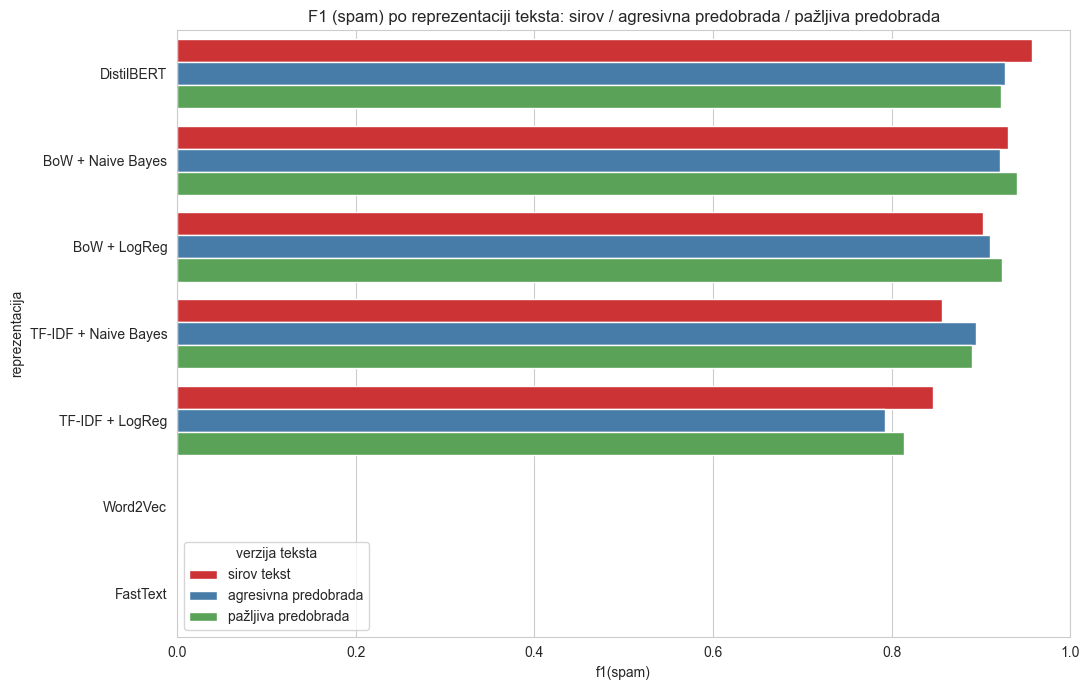

In [29]:
def extract_version(method_name):
    for _, tag in TEXT_VERSIONS:
        if f"({tag})" in method_name:
            return tag
    return "?"

results_df["verzija teksta"] = results_df["metoda"].apply(extract_version)
results_df["reprezentacija"] = results_df["metoda"].str.split(" (", regex=False).str[0]

version_order = [tag for _, tag in TEXT_VERSIONS]
fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(data=results_df, y="reprezentacija", x="f1(spam)", hue="verzija teksta", hue_order=version_order, palette="Set1", ax=ax)
ax.set_xlim(0, 1)
ax.set_title("F1 (spam) po reprezentaciji teksta: sirov / agresivna predobrada / pažljiva predobrada")
plt.tight_layout()
plt.show()

Grafik vizuelno potvrđuje: kod BoW stubova, zelena/narandžasta/plava (tri verzije teksta) pokazuju da pažljiva predobrada dosledno vodi ili je vrlo blizu vrha; kod DistilBERT-a redosled je obrnut (sirov > agresivna ≈ pažljiva); a Word2Vec/FastText ostaju spljošteni na nuli bez obzira na boju (verziju teksta).

## 17. Matrica konfuzije za najbolji model

Najbolja kombinacija: DistilBERT (mean-pool) + LogReg (sirov tekst) -> F1(spam) = 0.9572


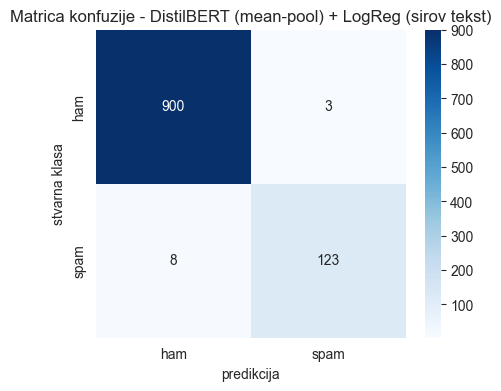

In [30]:
VERSION_TO_COL = {tag: col for col, tag in TEXT_VERSIONS}

best_method = results_df.iloc[0]["metoda"]
best_version = extract_version(best_method)
text_col = VERSION_TO_COL[best_version]
print("Najbolja kombinacija:", best_method, "-> F1(spam) =", results_df.iloc[0]["f1(spam)"])

if best_method.startswith("DistilBERT"):
    embeddings = get_bert_embeddings(df[text_col].tolist())
    emb_df = pd.DataFrame(embeddings, index=df.index)
    Xtr = emb_df.loc[train_idx].values
    Xte = emb_df.loc[test_idx].values
elif best_method.startswith("TF-IDF"):
    vectorizer = TfidfVectorizer(max_features=3000)
    Xtr = vectorizer.fit_transform(df.loc[train_idx, text_col])
    Xte = vectorizer.transform(df.loc[test_idx, text_col])
elif best_method.startswith("BoW"):
    vectorizer = CountVectorizer(max_features=3000)
    Xtr = vectorizer.fit_transform(df.loc[train_idx, text_col])
    Xte = vectorizer.transform(df.loc[test_idx, text_col])
else:
    token_lists = df[text_col].apply(str.split)
    ModelClass = Word2Vec if best_method.startswith("Word2Vec") else FastText
    w2v_model = ModelClass(sentences=token_lists.tolist(), vector_size=100, window=5, min_count=1, workers=4, seed=42)
    vectors = pd.Series([average_vector(toks, w2v_model) for toks in token_lists], index=df.index)
    Xtr = np.vstack(vectors.loc[train_idx].values)
    Xte = np.vstack(vectors.loc[test_idx].values)

clf = MultinomialNB() if "Naive Bayes" in best_method else LogisticRegression(max_iter=2000)
clf.fit(Xtr, y_train)
pred = clf.predict(Xte)

cm = confusion_matrix(y_test, pred, labels=["ham", "spam"])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["ham", "spam"], yticklabels=["ham", "spam"], ax=ax)
ax.set_xlabel("predikcija")
ax.set_ylabel("stvarna klasa")
ax.set_title(f"Matrica konfuzije - {best_method}")
plt.show()

Matrica konfuzije za najbolju kombinaciju (DistilBERT + LogReg, sirov tekst) na 1.034 test-poruke (903 ham, 131 spam): 900 ham tačno, 3 ham lažno označeno kao spam, 8 spam poruka propušteno (lažno ham), 123 spam tačno prepoznato.

## 18. Analiza značaja obeležja

Da bismo videli *koje* reči model stvarno koristi da prepozna spam, treniramo TF-IDF + logističku regresiju nad **pažljivom predobradom** i pogledamo koji tokeni imaju najveće pozitivne (spam) i najveće negativne (ham) koeficijente.

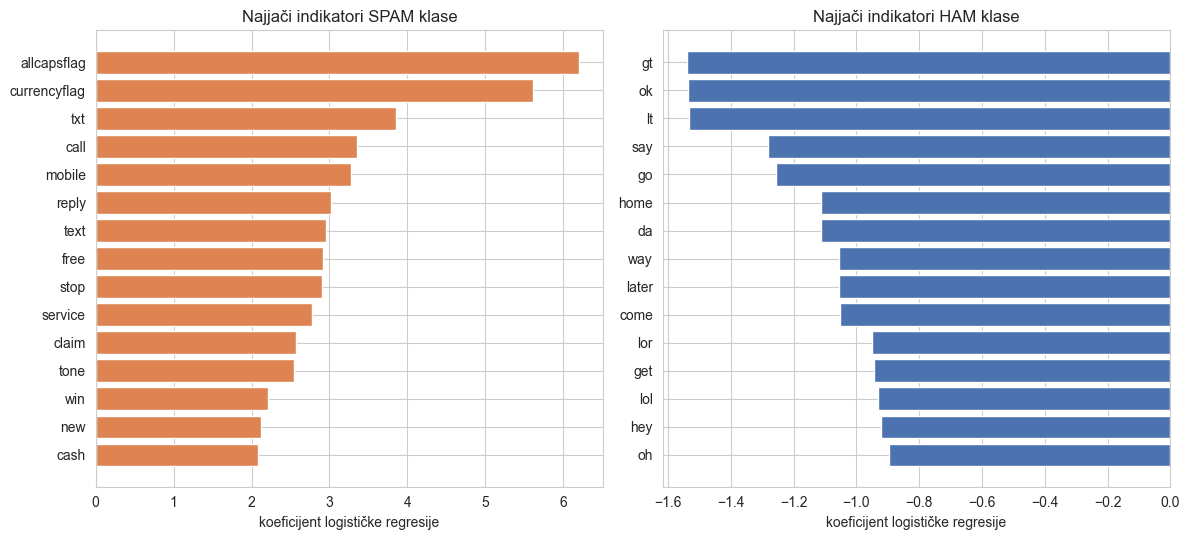

In [31]:
tfidf_smart = TfidfVectorizer(max_features=3000)
Xtr_smart = tfidf_smart.fit_transform(df.loc[train_idx, "text_smart"])
Xte_smart = tfidf_smart.transform(df.loc[test_idx, "text_smart"])

lr_smart = LogisticRegression(max_iter=1000)
lr_smart.fit(Xtr_smart, y_train)
evaluate(y_test, lr_smart.predict(Xte_smart), "TF-IDF + LogReg (pažljiva predobrada, za analizu obeležja)")

feature_names = np.array(tfidf_smart.get_feature_names_out())
coefs = lr_smart.coef_[0]
top_spam_idx = np.argsort(coefs)[-15:]
top_ham_idx = np.argsort(coefs)[:15]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
axes[0].barh(feature_names[top_spam_idx], coefs[top_spam_idx], color="#DD8452")
axes[0].set_title("Najjači indikatori SPAM klase")
axes[0].set_xlabel("koeficijent logističke regresije")
axes[1].barh(feature_names[top_ham_idx][::-1], coefs[top_ham_idx][::-1], color="#4C72B0")
axes[1].set_title("Najjači indikatori HAM klase")
axes[1].set_xlabel("koeficijent logističke regresije")
plt.tight_layout()
plt.show()

Dva apsolutno najjača prediktora spama u celom modelu nisu reči, već upravo oznake koje smo dodali - `ALLCAPSFLAG` i `CURRENCYFLAG`, obe daleko ispred najjače prave reči "txt". Velika slova i valutni simboli **jesu** među najjačim signalima spama - model im upravo zato dodeljuje najveće težine čim mu se ti signali ponude kao eksplicitna obeležja, umesto da budu obrisani zajedno sa ostalim "šumom". Iza njih slede očekivane reklamne reči ("call", "mobile", "reply", "free", "stop", "claim", "cash"). Na ham strani najjači indikatori su svakodnevne, konverzacijske reči ("ok", "say", "go", "home", "later", "lol") - bez ijedne reklamne reči.

## 19. Zaključak


**Kvalitet podataka nije samo lingvističko pitanje.** Otkriveno je 403 potpuna duplikata (7,2% skupa) čije bi zanemarivanje dovelo do curenja podataka i veštački naduvane ocene modela.

**Predobrada MOŽE da pomogne - ali samo ako je dizajnirana da čuva diskriminativni signal.** Agresivna predobrada koja slepo briše brojeve, velika slova i valutne simbole dosledno je bila najgora ili blizu najgore opcije, jer je brisala baš one obrasce za koje je odeljak 6 pokazao da su gotovo isključivo vezani za spam. Kada je ista lingvistička obrada (stop-reči, POS-svesna lematizacija) sprovedena uz **čuvanje** tog signala kao eksplicitnih oznaka (`ALLCAPSFLAG`, `CURRENCYFLAG`, `MULTIEXCLAIM`), rezultat je bio drugačiji: BoW + Naive Bayes sa pažljivom predobradom (F1 = 0,9398) postao je druga najbolja kombinacija, ispred sirovog teksta i ispred obe verzije DistilBERT-a sa bilo kakvom predobradom. Analiza značaja obeležja je ovo potvrdila brojkama: `ALLCAPSFLAG` i `CURRENCYFLAG` su ispali dva apsolutno najjača prediktora spama u celom modelu, jača od bilo koje pojedinačne reči.

**POS-svesna lematizacija je i tačnija i efikasnija.** Kada je lematizator dobio stvarnu gramatičku vrstu svake reči (iz konteksta cele rečenice), ispravno je lematizovao i glagolske i imeničke oblike, i pritom postigao veću redukciju rečnika (6.580 nasuprot 7.000 reči) nego naivna, isključivo imenička pretpostavka.

**Embeddinzi nisu magično rešenje bez dovoljno podataka - čak ni uz pažljivu predobradu.** Word2Vec/FastText, samostalno trenirani na ~4.100 poruka, ostali su na F1 = 0 u sve tri verzije teksta, što pokazuje da problem nije bio *kako* je tekst pripremljen, već da korpus prosto nije dovoljno velik da se nauči koristan vektorski prostor.

**Transformer modeli ne trebaju pomoć klasične predobrade - čak ni pažljive.** DistilBERT nad sirovim tekstom (F1 = 0,9572) je nadmašio sebe sa bilo kojom predobradom, uključujući i pažljivu verziju sa očuvanim signalima - ti signali modelu koji već "vidi" strukturu sirovog teksta kroz subword tokenizaciju jednostavno ne donose novu informaciju.

**Najvažnija poruka rada:** predobrada teksta nije ni univerzalno korisna ni univerzalno štetna - njen ishod zavisi od toga *koji* signal se čuva ili briše, i za *koju* reprezentaciju se priprema. Isti korak (uklanjanje brojeva i velikih slova) može biti presudna greška za jedan model (BoW) i potpuno nebitan za drugi (DistilBERT). Prava veština predobrade nije u tome da se primeni što više koraka, već da se svaki korak opravda time što se zna šta se njime čuva, a šta gubi.